In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from clash_filtering_new import calculate_distance, count_close_contacts

# 配置
data_dir = "PepSet_dimer"
binder_chain = "L"

In [2]:
pdb_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.pdb')])
print(f"Total PDB files: {len(pdb_files)}")

results = []
ideal_pdbs = []

for pdb in pdb_files:
    pdb_path = os.path.join(data_dir, pdb)

    # 检测目标链（非L链）
    with open(pdb_path) as f:
        lines = f.readlines()
    chain_ids = {line[21] for line in lines if line.startswith(('ATOM', 'HETATM'))}

    target_chain = next((c for c in chain_ids if c != binder_chain), None)
    if target_chain is None:
        print(f"{pdb}: 找不到目标链，跳过")
        continue

    # chain1=binder(L), chain2=target (遵循脚本约定)
    d, idx_matrix = calculate_distance(pdb_path, binder_chain, target_chain)
    if d is None:
        print(f"{pdb}: 距离计算失败，跳过")
        continue

    min_distance = np.min(d)
    min_idx = np.unravel_index(np.argmin(d), d.shape)
    atom1_info = idx_matrix[min_idx[0]][min_idx[1]][0]
    atom2_info = idx_matrix[min_idx[0]][min_idx[1]][1]

    clash_count = count_close_contacts(d, idx_matrix, vdw_scale=0.7)

    results.append({
        'pdb': pdb,
        'target_chain': target_chain,
        'min_distance': round(min_distance, 2),
        'clash_count': clash_count,
        'closest_pair': f"Binder{atom1_info[0]}_{atom1_info[1]} -- Target{atom2_info[0]}_{atom2_info[1]}"
    })

    if clash_count == 0:
        ideal_pdbs.append(pdb)

    print(f"{pdb}: min_dist={min_distance:.2f}, clashes={clash_count}")

print(f"\n通过clash筛选 (vdw_scale=0.7): {len(ideal_pdbs)}/{len(pdb_files)}")

Total PDB files: 170
1a0n.pdb: min_dist=4.67, clashes=0
1cqg.pdb: min_dist=2.70, clashes=0
1czy.pdb: min_dist=2.66, clashes=0
1ddv.pdb: min_dist=3.54, clashes=0
1eg4.pdb: min_dist=2.77, clashes=0
1f47.pdb: min_dist=2.79, clashes=0
1f8h.pdb: min_dist=3.25, clashes=0
1j2x.pdb: min_dist=4.07, clashes=0
1jd5.pdb: min_dist=2.84, clashes=0
1jq8.pdb: min_dist=2.40, clashes=1
1jw6.pdb: min_dist=2.48, clashes=0
1l2z.pdb: min_dist=3.82, clashes=0
1lb6.pdb: min_dist=2.81, clashes=0
1mf4.pdb: min_dist=2.36, clashes=3
1mv0.pdb: min_dist=3.14, clashes=0
1nrl.pdb: min_dist=4.75, clashes=0
1nvq.pdb: min_dist=2.64, clashes=0
1o0p.pdb: min_dist=2.79, clashes=0
1p7v.pdb: min_dist=2.53, clashes=0
1pmx.pdb: min_dist=3.85, clashes=0
1r17.pdb: min_dist=2.73, clashes=0
1rxz.pdb: min_dist=2.53, clashes=0
1t74.pdb: min_dist=4.86, clashes=0
1v1t.pdb: min_dist=2.86, clashes=0
1w80.pdb: min_dist=3.43, clashes=0
1yfn.pdb: min_dist=2.68, clashes=0
1ywi.pdb: min_dist=3.36, clashes=0
1ywo.pdb: min_dist=4.08, clashes=0

In [3]:
df_results = pd.DataFrame(results)
df_results

,pdb,target_chain,min_distance,clash_count,closest_pair
0,1a0n.pdb,B,4.67,0,Binder95_CA -- Target144_CB
1,1cqg.pdb,A,2.70,0,Binder65_N -- Target74_O
2,1czy.pdb,A,2.66,0,Binder205_O -- Target468_N
3,1ddv.pdb,A,3.54,0,Binder1006_O -- Target73_N
4,1eg4.pdb,A,2.77,0,Binder5_O -- Target189_N
...,...,...,...,...,...
165,6f4s.pdb,A,3.74,0,Binder139_CB -- Target308_CB
166,6f6d.pdb,A,2.82,0,Binder21_N -- Target1598_O
167,6fbk.pdb,A,2.46,0,Binder1261_O -- Target495_N
168,6g5g.pdb,B,3.89,0,Binder60_CB -- Target1244_O


In [6]:
vdw_scales = np.arange(0.5, 1.1, 0.1)
counts = []

for vdw_scale in vdw_scales:
    count_no_clash = 0
    for pdb in pdb_files:
        pdb_path = os.path.join(data_dir, pdb)

        with open(pdb_path) as f:
            lines = f.readlines()
        chain_ids = {line[21] for line in lines if line.startswith(('ATOM', 'HETATM'))}

        target_chain = next((c for c in chain_ids if c != binder_chain), None)
        if target_chain is None:
            continue

        d, idx_matrix = calculate_distance(pdb_path, binder_chain, target_chain, all_atoms=True)
        if d is None:
            continue

        if count_close_contacts(d, idx_matrix, vdw_scale=vdw_scale) == 0:
            count_no_clash += 1

    counts.append(count_no_clash / len(pdb_files))

print(counts)

[0.9941176470588236, 0.9882352941176471, 0.9588235294117647, 0.6941176470588235, 0.01764705882352941, 0.0, 0.0]


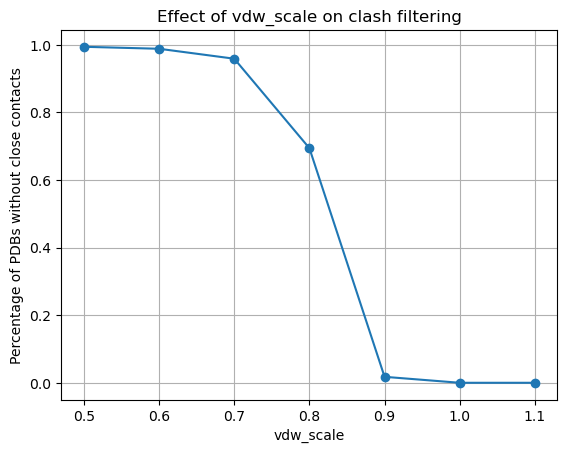

In [7]:
plt.plot(vdw_scales, counts, marker='o')
plt.xlabel('vdw_scale')
plt.ylabel('Percentage of PDBs without close contacts')
plt.title('Effect of vdw_scale on clash filtering')
plt.grid()
plt.show()